In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import seaborn as sns
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM,Bidirectional,GRU,Flatten
from tensorflow.keras.layers import Embedding
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.utils import to_categorical
import datetime
import io
import itertools
# import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

import sys
import os
# Obtener la ruta del directorio actual
os.chdir('..')
current_dir = os.getcwd()
print(current_dir)

# Construir la ruta relativa al directorio que quieres agregar
relative_dir = os.path.join(current_dir, 'mis_pkgs/')

# Agregar la ruta relativa al sys.path
sys.path.insert(0, relative_dir)

from MIOPATIA_db import DB_management as db 
np.log2(10)

2025-03-14 08:48:25.775517: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-14 08:48:25.775580: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-14 08:48:25.837776: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-14 08:48:25.973832: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-14 08:48:27.136186: W tensorflow/compiler/tf2

/home/rgadea/nuevas_investigaciones_alimentos_2024


3.321928094887362

In [ ]:
numero_muestras=150
numero_clases=2
entrada=[3,4]
numero_entradas = 2
numero_epochs=5000

Voy a quedarme con los 50 atunes P1 para obtener conjunto de training y validacion

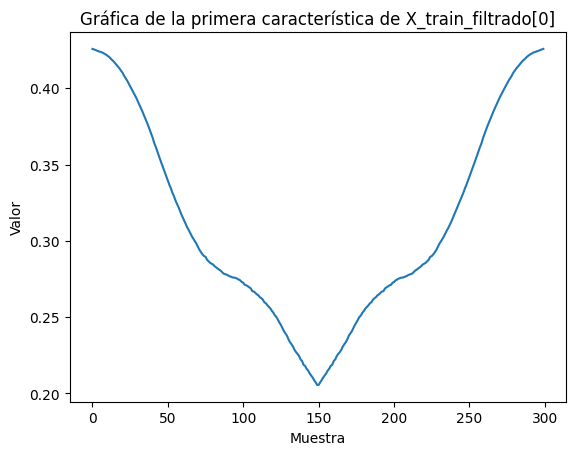

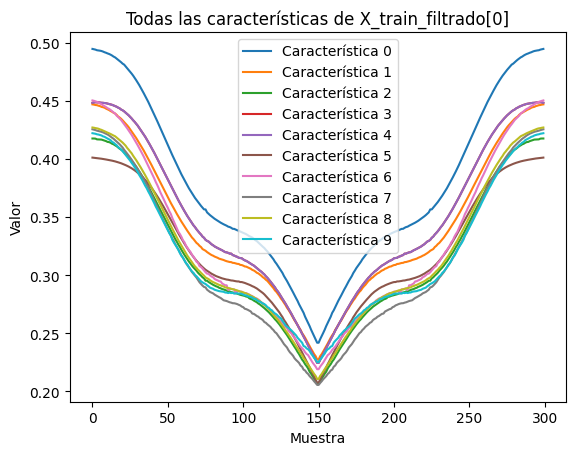

In [3]:
filename = "COPIA_PANDAS/medidas_agilent_2023_y_2024_201_puntos_clasificados.hdf"
with pd.HDFStore(filename,complib="zlib",complevel=4) as hdf_db:
    pre_p_e1  = hdf_db.get('data/pollos_estado')
    pre_p_e1 = pre_p_e1.loc[pre_p_e1['Pollo'] != 0]
    # p_e =pre_p_e1.drop_duplicates(subset = ['Pollo', 'Medida'],  keep = 'last').reset_index(drop = True)
    t    = hdf_db.get('data/tabla')
    X_train=[]

    y_train=[]

    estados=[]
    x=0
    for index, row in pre_p_e1.iterrows():   # El primer registro no se toma en cuenta porque es basura
        Primero = int(row['Primero'])
        Ultimo  = int(row['Ultimo'])
        estado  = int(row['Estado'])
        #print(Primero)
        #print(Ultimo)
        #print(estado)
        if estado<5:
            if numero_clases==2:
                if estado == 0 or estado== 1:
                    target = 0
                else:
                    target = 1
            else:
                target=estado
            pepito=np.array(t.iloc[Primero+50:Primero+200])
            # Diezmar pepito a la mitad
            # pepito = pepito[::2]
            # # Duplicar pepito concatenándolo con su versión invertida
            pepito = np.concatenate((pepito, np.flipud(pepito)))

            X_train.append(pepito[:,entrada])
            y_train.append(target)
            estados.append(estado)
            y_train_to_categorical = to_categorical(y_train)
            x=x+1

X_train_filtrado=np.zeros((x,numero_muestras*2,numero_entradas))
X_train = np.array(X_train)
y_train = np.array(y_train)
X_train_filtrado[:,:,0] =((np.log(X_train[:,:,0])) /16)-0.3
X_train_filtrado[:,:,1]=-X_train[:,:,1]*2*180/(np.pi*256)

#y_train_filtrado = y_train
y_train_filtrado = y_train_to_categorical


scaler = MinMaxScaler(feature_range=(0, 1))
#scaler = StandardScaler()



#data1=np.concatenate((X_train_filtrado,X_test_filtrado1),axis=0) 

data_2d = X_train_filtrado.reshape(-1, X_train_filtrado.shape[-1])
normalized_data_2d = scaler.fit_transform(data_2d)



X_train_Normalizado=normalized_data_2d.reshape(X_train_filtrado.shape)
y_train_Normalizado=y_train_filtrado

# print(X_train_filtrado[1])
plt.plot(X_train_filtrado[7][:, 0])
plt.title('Gráfica de la primera característica de X_train_filtrado[0]')
plt.xlabel('Muestra')
plt.ylabel('Valor')
plt.show()

# Si quieres plotear todas las características de X_train_filtrado[0] en la misma gráfica:
for i in range(10):
    plt.plot(X_train_filtrado[i][:, 0], label=f'Característica {i}')
plt.title('Todas las características de X_train_filtrado[0]')
plt.xlabel('Muestra')
plt.ylabel('Valor')
plt.legend()
plt.show()

Vamos a hacer los conjuntos de entrenamiento validacion y test

In [4]:
# Divide el dataset en entrenamiento y temporal (test+validación)
# X_temp, X_test_def, y_temp, y_test_def = train_test_split(X_train_Normalizado, y_train_Normalizado, test_size=0.2, stratify=y_train_Normalizado, random_state=42)

# Divide el dataset temporal en validación y test
X_train_def, X_val_def, y_train_def, y_val_def, estados_train, estados_val = train_test_split(X_train_filtrado, y_train_filtrado, estados, test_size=0.20, stratify=y_train_filtrado, random_state=42)

# Ahora, X_train, X_val y X_test contienen los datos de entrada para los conjuntos de entrenamiento, validación y prueba, respectivamente.
# y_train, y_val y y_test contienen las clases correspondientes.

In [5]:
print(X_train_def.shape)
print(X_val_def.shape)

print(y_train_def.shape)
print(y_val_def.shape)


(147, 300, 2)
(37, 300, 2)
(147, 2)
(37, 2)


In [6]:
factor_aprendizaje=0.001
dimension_LSTM=16
dimension_dense1=320
dimension_dense2=32
algoritmo='rmsprop'
supermax=8*4
lossfunction='categorical_crossentropy'
def create_model():

    model = Sequential()
    model.add(GRU(dimension_LSTM, return_sequences=True,recurrent_regularizer='L1L2',input_shape=(numero_muestras*2, numero_entradas)))
    model.add(Flatten())  
    #model.add(GRU(50, return_sequences=True))
    #model.add(GRU(50, return_sequences=False, recurrent_regularizer='L2'))
    model.add(Dense(dimension_dense1, activation='tanh', activity_regularizer='L1L2'))
    model.add(Dense(dimension_dense2, activation='tanh', activity_regularizer='L1L2'))
    model.add(Dense(numero_clases, activation='sigmoid'))
    model.compile(loss=lossfunction, optimizer=algoritmo, metrics=['accuracy',
                              tf.keras.metrics.Recall(class_id=0),
                              tf.keras.metrics.Recall(class_id=1) #,
                              #tfa.metrics.F1Score(num_classes=numero_clases,average='macro', threshold=0.5)
                              ])
    model.optimizer.lr=(factor_aprendizaje)
    return model

model=create_model()

2025-03-14 08:48:31.937669: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-03-14 08:48:32.133801: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-03-14 08:48:32.133857: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-03-14 08:48:32.136207: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-03-14 08:48:32.136294: I external/local_xla/xla/stream_executor

In [7]:

experimento="Experimento1"
fecha=datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
logdir="./logs/defs_2025/{}_{}".format(experimento,fecha)
tensorboard_callback=tf.keras.callbacks.TensorBoard(log_dir=logdir, histogram_freq=1)
# file_writer_cm = tf.summary.create_file_writer(logdir + '/cm')


In [8]:
if numero_clases==2:
    class_names=['Buenos', 'Malos']
else:
    class_names=['A', 'B+', 'B', 'B-','C']

In [9]:
lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.95,
    patience=1000,
    min_lr=0.0001
)
early_stop=tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', min_delta=0, patience=2000, verbose=2, mode='auto', baseline=None, restore_best_weights=True)
model.fit(X_train_def, y_train_def, epochs=numero_epochs, batch_size=20, callbacks=[tensorboard_callback,lr_callback,early_stop], validation_data=(X_val_def, y_val_def))
# Final evaluation of the model 
scores = model.evaluate(X_val_def, y_val_def, verbose=2)
print("Accuracy: %.2f%%" % (scores[1]*100))

Epoch 1/2000


2025-03-14 08:48:35.286202: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2025-03-14 08:48:35.437489: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f6488782e90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-03-14 08:48:35.437531: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce GTX 1070 Ti, Compute Capability 6.1
2025-03-14 08:48:35.454430: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1741938515.510726    3905 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8/8 [==============================] - 3s 126ms/step - loss: 1.2142 - accuracy: 0.5442 - recall: 0.7294 - recall_1: 0.7419 - val_loss: 0.6897 - val_accuracy: 0.5676 - val_recall: 1.0000 - val_recall_1: 1.0000 - lr: 0.0010
Epoch 2/2000
8/8 [==============================] - 0s 57ms/step - loss: 0.7426 - accuracy: 0.4218 - recall: 1.0000 - recall_1: 1.0000 - val_loss: 0.7468 - val_accuracy: 0.5946 - val_recall: 1.0000 - val_recall_1: 1.0000 - lr: 0.0010
Epoch 3/2000
8/8 [==============================] - 0s 57ms/step - loss: 0.7081 - accuracy: 0.5850 - recall: 1.0000 - recall_1: 0.8710 - val_loss: 0.6865 - val_accuracy: 0.5676 - val_recall: 1.0000 - val_recall_1: 1.0000 - lr: 0.0010
Epoch 4/2000
8/8 [==============================] - 0s 56ms/step - loss: 0.6860 - accuracy: 0.5714 - recall: 1.0000 - recall_1: 1.0000 - val_loss: 0.6743 - val_accuracy: 0.5946 - val_recall: 1.0000 - val_recall_1: 1.0000 - lr: 0.0010
Epoch 5/2000
8/8 [==============================] - 0s 57ms/step - loss: 0.6

In [10]:
idea=model.metrics_names
print(model.metrics)
print(idea)

[<keras.src.metrics.base_metric.Mean object at 0x7f653d3c6ad0>, <keras.src.metrics.base_metric.MeanMetricWrapper object at 0x7f64dc171300>, <keras.src.metrics.confusion_metrics.Recall object at 0x7f653d3c4880>, <keras.src.metrics.confusion_metrics.Recall object at 0x7f653d3c5c30>]
['loss', 'accuracy', 'recall', 'recall_1']


In [11]:
y_pred = model.predict(X_val_def)
#y_pred1=y_pred[:,-1]
y_pred2=np.argmax(y_pred,axis=1)
#y_pred2=np.where(y_pred>0,1,0)
#y_pred2=y_pred2[:,-1]
y_test_def2=np.argmax(y_val_def,axis=1)
#y_test_def2=np.where(y_test_def>0,1,0)
print(y_pred.shape)
print(y_pred2.shape)
print(y_test_def2.shape)
#print(y_test_def[25])
#print(y_val_def)
#print(y_pred)

2/2 [==============================] - 0s 9ms/step
(37, 2)
(37,)
(37,)


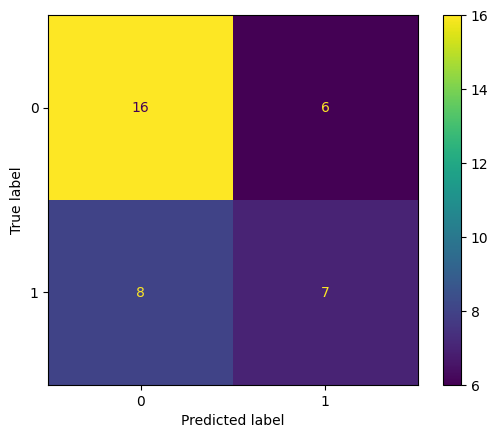

In [12]:
#docs_infra: no_execute
if numero_clases==2:
    classes = [0, 1]
else:   
    classes = [0, 1, 2, 3, 4]
#classes = [0, 1]
cm=confusion_matrix(y_test_def2, y_pred2,labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [13]:
from sklearn.metrics import classification_report
if numero_clases==2:
    target_names = ['Buenos', 'Malos']
else:   
    target_names = ['A', 'B+', 'B', 'B-','C']
print(classification_report(y_test_def2, y_pred2, target_names=target_names, digits=4))

              precision    recall  f1-score   support

      Buenos     0.6667    0.7273    0.6957        22
       Malos     0.5385    0.4667    0.5000        15

    accuracy                         0.6216        37
   macro avg     0.6026    0.5970    0.5978        37
weighted avg     0.6147    0.6216    0.6163        37



In [ ]:
# Identificar falsos positivos y falsos negativos
estados_val = np.array(estados_val)
false_positives = np.where((y_pred2 == 1) & (y_test_def2 == 0))[0]
false_negatives = np.where((y_pred2 == 0) & (y_test_def2 == 1))[0]
estados=np.array(estados)
false_positives_states = estados_val[false_positives]
false_negatives_states = estados_val[false_negatives]


print(f"  Falsos positivos (estado): {false_positives_states}")
print(f"  Falsos negativos (estado): {false_negatives_states}")

  Falsos positivos (estado): [2 2 2 2 2 2]
  Falsos negativos (estado): [2 2 2 2 2 2 2 2]


In [15]:
#model.save('idea.h5')  # creates a HDF5 file 'my_model.h5'
model.save('modelos/modelo_perfecto_{}_{}.h5'.format(experimento,fecha)) 

/home/rgadea/.local/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [16]:
#este modo de guardar no funciona en esta version de tensorflow
model.save('modelos/modelo_perfecto_para_matlab_{}_{}'.format(experimento,fecha)) 

INFO:tensorflow:Assets written to: modelos/modelo_perfecto_para_matlab_Experimento1_20250314-084833/assets


INFO:tensorflow:Assets written to: modelos/modelo_perfecto_para_matlab_Experimento1_20250314-084833/assets


In [17]:
import scipy.io as sio

In [18]:
savedict={'X_val_def':X_val_def,'y_val_def':y_val_def}

sio.savemat('Val_Normalizado_{}_{}.mat'.format(experimento,fecha),savedict)

In [19]:
#salida=model.predict(X_test_def)    
inputs=model.layers[0].input
# Asume que model es tu modelo original y que quieres la salida de la primera capa
output_layer = model.layers[0].output

# Crea un nuevo modelo que tenga la misma entrada que el modelo original, pero cuya salida sea la salida de la capa que te interesa
intermediate_model = tf.keras.Model(inputs=inputs, outputs=output_layer)

#este modo de guardar no funciona en esta version de tensorflow
intermediate_model.save('modelos/modelo_perfecto_para_matlab__{}_{}'.format(experimento,fecha)) 

INFO:tensorflow:Assets written to: modelos/modelo_perfecto_para_matlab__Experimento1_20250314-084833/assets


INFO:tensorflow:Assets written to: modelos/modelo_perfecto_para_matlab__Experimento1_20250314-084833/assets


In [20]:
savedict={'X_train_filtrado':X_val_def,'y_train_filtrado':y_val_def}

sio.savemat('Train_Normalizado_{}_{}.mat'.format(experimento,fecha),savedict)

In [21]:
from sklearn.model_selection import train_test_split

from sklearn.model_selection import KFold
from sklearn.metrics import classification_report,recall_score

In [22]:
inputs=X_train_filtrado.reshape(X_train_filtrado.shape[0],-1)
targets=y_train_filtrado

In [23]:
lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.95,
    patience=1000,
    min_lr=0.0001
)
early_stop=tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', min_delta=0, patience=2000, verbose=2, mode='auto', baseline=None, restore_best_weights=True)
# Define the K-fold Cross Validator
kfold = KFold(n_splits=10, shuffle=True)

# Inicializar listas para almacenar resultados
conf_matrices = []
misclassified_states_all_folds = []
false_positives_all_folds = []
false_negatives_all_folds = []
# Define per-fold score containers
acc_per_fold = []
loss_per_fold = []
sensibilidad_YAKE_per_fold=[]
sensibilidad_no_YAKE_per_fold=[]
casos_target_0=[]
casos_target_1=[]
casos_predichos_0=[]
casos_predichos_1=[]
# K-fold Cross Validation model evaluation
fold_no = 1
for train, test in kfold.split(inputs, targets):
    model=create_model()
     # Generate a print
    print('------------------------------------------------------------------------')
    print(f'Training for fold {fold_no} ...')
    inputs_good=inputs.reshape(X_train_filtrado.shape)
    estados_train, estados_test = estados[train], estados[test]

    # Fit data to model
    history = model.fit(inputs_good[train], targets[train],
              batch_size=20,
              epochs=numero_epochs,
              callbacks=[early_stop,lr_callback, tensorboard_callback],
              validation_data=(inputs_good[test],targets[test])
              )
    if numero_clases==2:
        target_names = ['Buenos', 'Malos']
    else:   
        target_names = ['A', 'B+', 'B', 'B-','C']
    y_pred = model.predict(inputs_good[test])
    y_pred2=np.argmax(y_pred,axis=1)
    y_test_def2=np.argmax(targets[test],axis=1)
    print(classification_report(y_test_def2, y_pred2, target_names=target_names, digits=4))
    scores2=recall_score(y_test_def2, y_pred2, average=None)
    # Generate generalization metrics
    scores = model.evaluate(inputs_good[test], targets[test], verbose=0)
    print(f'Score for fold {fold_no}: {model.metrics_names[0]} of {scores[0]}; {model.metrics_names[1]} of {scores[1]*100}%')
    print(scores[2])
    print(scores[3])
    print(scores2[0])
    print(scores2[1])
   # print(scores[4])
    acc_per_fold.append(scores[1] * 100)
    loss_per_fold.append(scores[0])
    sensibilidad_no_YAKE_per_fold.append(scores2[0] * 100)
    sensibilidad_YAKE_per_fold.append(scores2[1] * 100)
    casos_target_0.append(np.sum(y_test_def2==0))
    casos_target_1.append(np.sum(y_test_def2==1))
    casos_predichos_0.append(np.sum(y_pred2==0))    
    casos_predichos_1.append(np.sum(y_pred2==1))    


        # Calcular la matriz de confusión
    conf_matrix = confusion_matrix(y_test_def2, y_pred2)
    conf_matrices.append(conf_matrix)

    # Identificar las muestras mal clasificadas
    misclassified_indices = np.where(y_pred2 != y_test_def2)[0]
    misclassified_states = estados_test[misclassified_indices]
    misclassified_states_all_folds.append(misclassified_states)

        # Identificar falsos positivos y falsos negativos
    false_positives = np.where((y_pred2 == 1) & (y_test_def2 == 0))[0]
    false_negatives = np.where((y_pred2 == 0) & (y_test_def2 == 1))[0]
    false_positives_states = estados_test[false_positives]
    false_negatives_states = estados_test[false_negatives]
    false_positives_all_folds.append(false_positives_states)
    false_negatives_all_folds.append(false_negatives_states)

    print(f"Fold {fold_no}:")
    print(f"  Índices Falsos positivos : {false_positives}")
    print(f"  Índices Falsos negativos : {false_negatives}")
    print(f"  Falsos positivos (estado): {false_positives_states}")
    print(f"  Falsos negativos (estado): {false_negatives_states}")
    # Increase fold number
    fold_no = fold_no + 1

------------------------------------------------------------------------
Training for fold 1 ...
Epoch 1/2000
9/9 [==============================] - 2s 103ms/step - loss: 1.4211 - accuracy: 0.4788 - recall_2: 0.8511 - recall_3: 0.1549 - val_loss: 0.7321 - val_accuracy: 0.2632 - val_recall_2: 0.2308 - val_recall_3: 0.8333 - lr: 0.0010
Epoch 2/2000
9/9 [==============================] - 1s 61ms/step - loss: 0.7050 - accuracy: 0.5030 - recall_2: 0.9043 - recall_3: 0.1831 - val_loss: 0.6581 - val_accuracy: 0.6842 - val_recall_2: 1.0000 - val_recall_3: 0.0000e+00 - lr: 0.0010
Epoch 3/2000
9/9 [==============================] - 0s 47ms/step - loss: 0.6877 - accuracy: 0.5697 - recall_2: 0.6915 - recall_3: 0.0000e+00 - val_loss: 0.6676 - val_accuracy: 0.6842 - val_recall_2: 1.0000 - val_recall_3: 0.0000e+00 - lr: 0.0010
Epoch 4/2000
9/9 [==============================] - 0s 54ms/step - loss: 0.6864 - accuracy: 0.5697 - recall_2: 1.0000 - recall_3: 0.0000e+00 - val_loss: 0.6855 - val_accuracy: 

KeyboardInterrupt: 

In [ ]:
# == Provide average scores ==
print('------------------------------------------------------------------------')
print('Score per fold')
for i in range(0, len(acc_per_fold)):
  print('------------------------------------------------------------------------')
  print(f'> Fold {i+1} - Loss: {loss_per_fold[i]:.3f} - Accuracy: {acc_per_fold[i]:.3f}%')
print('------------------------------------------------------------------------')
print('Average scores for all folds:')
print(f'> Accuracy: {np.mean(acc_per_fold):.3f} (+- {np.std(acc_per_fold):.3f})')
print(f'> Loss: {np.mean(loss_per_fold):.3f}')
print('------------------------------------------------------------------------')

------------------------------------------------------------------------
Score per fold
------------------------------------------------------------------------
> Fold 1 - Loss: 0.735 - Accuracy: 78.947%
------------------------------------------------------------------------
> Fold 2 - Loss: 0.603 - Accuracy: 78.947%
------------------------------------------------------------------------
> Fold 3 - Loss: 0.835 - Accuracy: 63.158%
------------------------------------------------------------------------
> Fold 4 - Loss: 0.476 - Accuracy: 84.211%
------------------------------------------------------------------------
> Fold 5 - Loss: 0.701 - Accuracy: 77.778%
------------------------------------------------------------------------
> Fold 6 - Loss: 0.453 - Accuracy: 94.444%
------------------------------------------------------------------------
> Fold 7 - Loss: 1.104 - Accuracy: 77.778%
------------------------------------------------------------------------
> Fold 8 - Loss: 0.646 - Ac

In [ ]:
# == Provide average scores ==
print('------------------------------------------------------------------------')
print('Score per fold')
for i in range(0, len(sensibilidad_YAKE_per_fold)):
  print('------------------------------------------------------------------------')
  print(f'> Fold {i+1} - Sensibilidad YAKE: {sensibilidad_YAKE_per_fold[i]:.2f} - Sensibilidad NOYAKE: {sensibilidad_no_YAKE_per_fold[i]:.2f}%')
  print(f'> Fold {i+1} - Lomos sin Yake: {casos_target_0[i]} - Casos con Yake: {casos_target_1[i]}')
  print(f'> Fold {i+1} - Lomos sin Yake predichos: {casos_predichos_0[i]} - Casos con Yake predichos: {casos_predichos_1[i]}')  
  print(f'Falsos positivos (estado): {false_positives_all_folds[i]}')
  print(f'Falsos negativos (estado): {false_negatives_all_folds[i]}')
  print('------------------------------------------------------------------------')
print('------------------------------------------------------------------------')
print('Average scores for all folds:')
print(f'> Sensibilidad YAKE: {np.mean(sensibilidad_YAKE_per_fold):.2f} (+- {np.std(sensibilidad_YAKE_per_fold):.2f})')
print(f'> Sensibilidad NOYAKE: {np.mean(sensibilidad_no_YAKE_per_fold):.2f} (+- {np.std(sensibilidad_no_YAKE_per_fold):.2f})')
print('------------------------------------------------------------------------')

------------------------------------------------------------------------
Score per fold
------------------------------------------------------------------------
> Fold 1 - Sensibilidad YAKE: 57.14 - Sensibilidad NOYAKE: 91.67%
> Fold 1 - Lomos sin Yake: 12 - Casos con Yake: 7
> Fold 1 - Lomos sin Yake predichos: 14 - Casos con Yake predichos: 5
------------------------------------------------------------------------
> Fold 2 - Sensibilidad YAKE: 50.00 - Sensibilidad NOYAKE: 100.00%
> Fold 2 - Lomos sin Yake: 11 - Casos con Yake: 8
> Fold 2 - Lomos sin Yake predichos: 15 - Casos con Yake predichos: 4
------------------------------------------------------------------------
> Fold 3 - Sensibilidad YAKE: 25.00 - Sensibilidad NOYAKE: 90.91%
> Fold 3 - Lomos sin Yake: 11 - Casos con Yake: 8
> Fold 3 - Lomos sin Yake predichos: 16 - Casos con Yake predichos: 3
------------------------------------------------------------------------
> Fold 4 - Sensibilidad YAKE: 66.67 - Sensibilidad NOYAKE: 10

In [ ]:
# Visualizar la matriz de confusión acumulada
accumulated_conf_matrix = np.sum(conf_matrices, axis=0)
plt.figure(figsize=(10, 7))
sns.heatmap(accumulated_conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Accumulated Confusion Matrix')
plt.show()

In [ ]:
print(model.metrics_names)
print(scores)

['loss', 'accuracy', 'recall_20', 'recall_21']
[0.5974295139312744, 0.8333333134651184, 0.800000011920929, 0.875]
